Training data shape: (657069, 32)
Testing data shape: (164268, 32)

Training CatBoost model... (This will take a minute or two)
0:	learn: 183.9234544	total: 175ms	remaining: 1m 27s
100:	learn: 121.1436246	total: 2.5s	remaining: 9.88s
200:	learn: 117.5031210	total: 4.77s	remaining: 7.1s
300:	learn: 115.1300830	total: 7.01s	remaining: 4.64s
400:	learn: 113.1971377	total: 9.35s	remaining: 2.31s
499:	learn: 111.6959142	total: 11.7s	remaining: 0us

--- CatBoost Performance ---
Training R^2: 0.6494
Testing R^2:  0.6465
Testing RMSE: $112.10
Testing MAE:  $77.25
Testing MAPE: 26.37%
Predictions strictly within $25: 23.97%


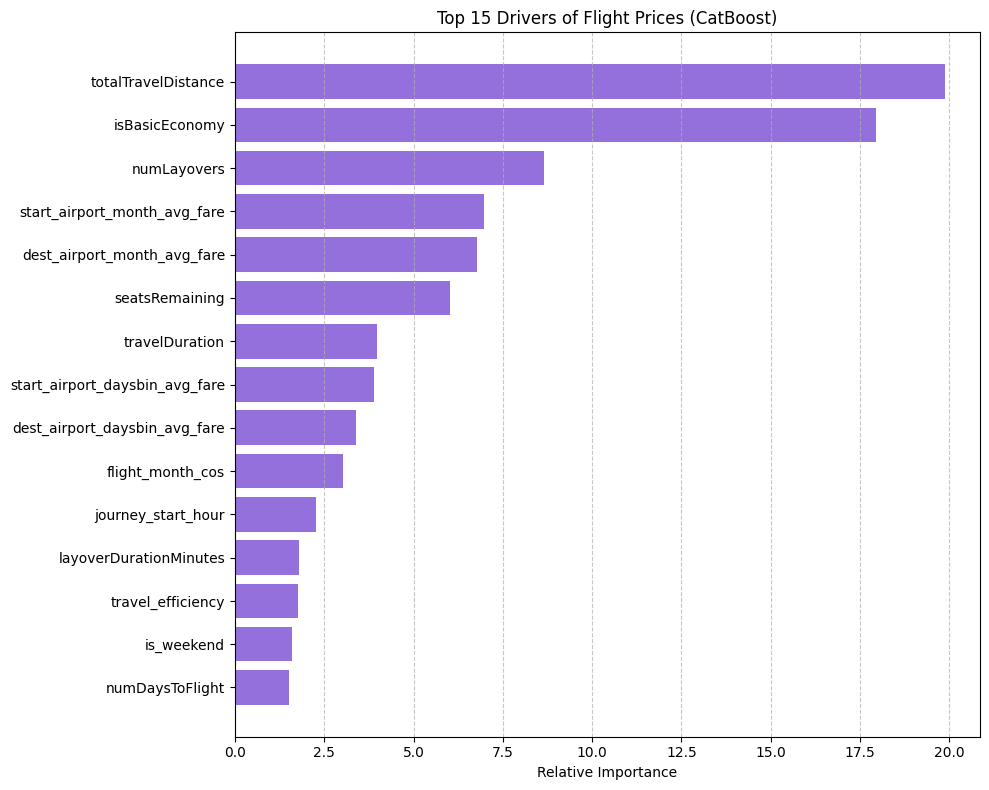

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. Define Features and Target (Assuming X_32 and y are ready)
df = pd.read_parquet("final_32_columns_no_outliers.parquet")

# Target
y = df["totalFare"].copy()

# Features (32-column set without target)
X_32 = df.drop(columns=["totalFare"]).copy()
# 1. Define Features and Target (Using X_32 from your previous step)
# Assuming X_32 and y are already in your environment
X = X_32.copy()
y_target = y.copy()
# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 3. Initialize the CatBoost Regressor
# - iterations: Equivalent to n_estimators in XGBoost
# - depth: How deep each tree grows
# - verbose=100: Prints progress every 100 trees so your screen isn't flooded
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100 
)

# 4. Train the Model
print("\nTraining CatBoost model... (This will take a minute or two)")
cat_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred_train = cat_model.predict(X_train)
y_pred_test = cat_model.predict(X_test)

# 6. Evaluate Performance (Including new Business Metrics)
print("\n--- CatBoost Performance ---")
print(f"Training R^2: {r2_score(y_train, y_pred_train):.4f}")
print(f"Testing R^2:  {r2_score(y_test, y_pred_test):.4f}")
print(f"Testing RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Testing MAE:  ${mean_absolute_error(y_test, y_pred_test):.2f}")

# --- THE NEW BUSINESS METRICS ---
mape = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"Testing MAPE: {mape * 100:.2f}%")

# Calculate what percentage of our predictions were within $25 of the true price
within_25 = np.mean(np.abs(y_test - y_pred_test) <= 25) * 100
print(f"Predictions strictly within $25: {within_25:.2f}%")
# ---------------------------------

# 7. Feature Importance Visualization
importances = cat_model.get_feature_importance()
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='mediumpurple')
plt.xlabel('Relative Importance')
plt.title('Top 15 Drivers of Flight Prices (CatBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Randomized cv

Loading data...
Full Training data shape: (643928, 32)
Testing data shape: (160982, 32)

Creating a 20% sample for safe tuning...
Starting lightweight Randomized Search on 20% sample...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END depth=10, iterations=300, l2_leaf_reg=3, learning_rate=0.1; total time=   7.7s
[CV] END depth=10, iterations=300, l2_leaf_reg=3, learning_rate=0.1; total time=   6.9s
[CV] END depth=10, iterations=300, l2_leaf_reg=3, learning_rate=0.1; total time=   7.1s
[CV] END depth=6, iterations=300, l2_leaf_reg=7, learning_rate=0.05; total time=   1.6s
[CV] END depth=6, iterations=300, l2_leaf_reg=7, learning_rate=0.05; total time=   4.0s
[CV] END depth=6, iterations=300, l2_leaf_reg=7, learning_rate=0.05; total time=   3.3s
[CV] END depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.05; total time=   3.3s
[CV] END depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.05; total time=   3.8s
[CV] END depth=6, iterations=300, l2_leaf_reg=3, l

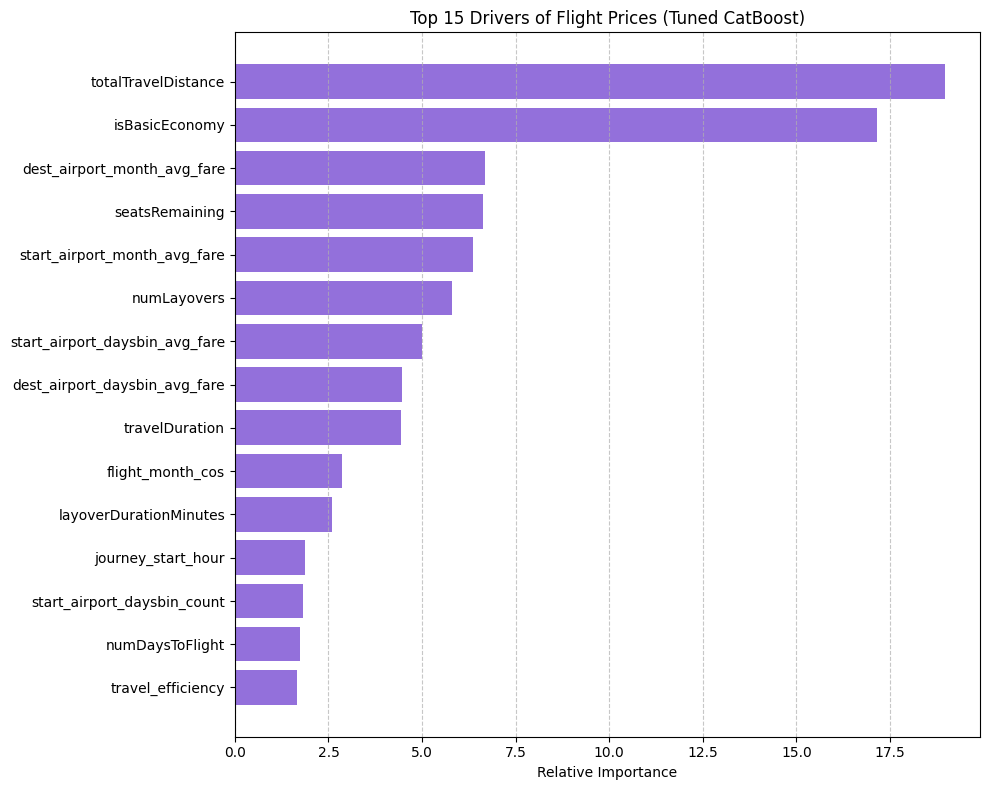

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc # Garbage collector for memory management
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# ---------------------------------------------------------
# 1. Load Data & Define Features/Target
# ---------------------------------------------------------
print("Loading data...")
df = pd.read_parquet("final_32_columns_no_outliers.parquet")

# Target
y = df["totalFare"].copy()

# Features (32-column set without target)
X = df.drop(columns=["totalFare"]).copy()

# Standard 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Full Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# ---------------------------------------------------------
# 2. MEMORY-SAFE HYPERPARAMETER TUNING (20% Sample)
# ---------------------------------------------------------
print("\nCreating a 20% sample for safe tuning...")
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=0.2, random_state=42)

# Define the parameter grid for CatBoost
param_distributions = {
    'iterations': [300, 500, 700],         # Number of trees
    'depth': [6, 8, 10],                   # Depth of trees
    'learning_rate': [0.03, 0.05, 0.1],    # Step size
    'l2_leaf_reg': [1, 3, 5, 7]            # L2 Regularization to prevent overfitting
}

# Base model for tuning (verbose=False keeps the terminal clean during CV)
# thread_count=-1 uses all CPU cores for training
base_cat = CatBoostRegressor(random_seed=42, thread_count=-1, verbose=False)

# n_jobs=1 ensures Python only tests ONE combination at a time, saving RAM
random_search = RandomizedSearchCV(
    estimator=base_cat,
    param_distributions=param_distributions,
    n_iter=5,  # Tests 5 random combinations to save time and memory
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1 
)

print("Starting lightweight Randomized Search on 20% sample...")
random_search.fit(X_tune, y_tune)

print("\n🎉 Best Hyperparameters Found:")
best_params = random_search.best_params_
for param, value in best_params.items():
    print(f" - {param}: {value}")

# Clean up memory before final training
del X_tune, y_tune, random_search
gc.collect()

# ---------------------------------------------------------
# 3. FINAL TRAINING ON 100% DATA
# ---------------------------------------------------------
print("\nTraining final CatBoost model on full 100% training dataset with best parameters...")

# Create final model using the winning settings. 
# verbose=100 so you can track progress!
final_cat = CatBoostRegressor(
    **best_params,
    random_seed=42,
    thread_count=-1,
    verbose=100
)

final_cat.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Predictions and Evaluation
# ---------------------------------------------------------
y_pred_train = final_cat.predict(X_train)
y_pred_test = final_cat.predict(X_test)

print("\n--- Ultimate Tuned CatBoost Performance ---")
print(f"Training R^2: {r2_score(y_train, y_pred_train):.4f}")

# Calculate Testing Metrics
r2_test = r2_score(y_test, y_pred_test)
print(f"Testing R^2:  {r2_test:.4f}")

# Calculate Adjusted R2 (as requested in a previous chat!)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
print(f"Testing Adjusted R^2: {adjusted_r2:.4f}")

print(f"Testing RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Testing MAE:  ${mean_absolute_error(y_test, y_pred_test):.2f}")

mape = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"Testing MAPE: {mape * 100:.2f}%")

within_25 = np.mean(np.abs(y_test - y_pred_test) <= 25) * 100
print(f"Predictions strictly within $25: {within_25:.2f}%")

# ---------------------------------------------------------
# 5. Feature Importance Visualization
# ---------------------------------------------------------
importances = final_cat.get_feature_importance()
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='mediumpurple')
plt.xlabel('Relative Importance')
plt.title('Top 15 Drivers of Flight Prices (Tuned CatBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [3]:
# 1. Make predictions on both train and test sets
y_pred_train = final_cat.predict(X_train)
y_pred_test = final_cat.predict(X_test)

# 2. Calculate Standard R-Squared
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# 3. Calculate Adjusted R-Squared for the Test Set
# n = number of rows in test set, p = number of features (32)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_test_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

# 4. Print them out cleanly!
print("\n--- Model Variance Explained (R-Squared) ---")
print(f"Training R^2:         {train_r2:.4f}")
print(f"Testing R^2:          {test_r2:.4f}")
print(f"Testing Adjusted R^2: {adjusted_test_r2:.4f}")


--- Model Variance Explained (R-Squared) ---
Training R^2:         0.7282
Testing R^2:          0.7198
Testing Adjusted R^2: 0.7198


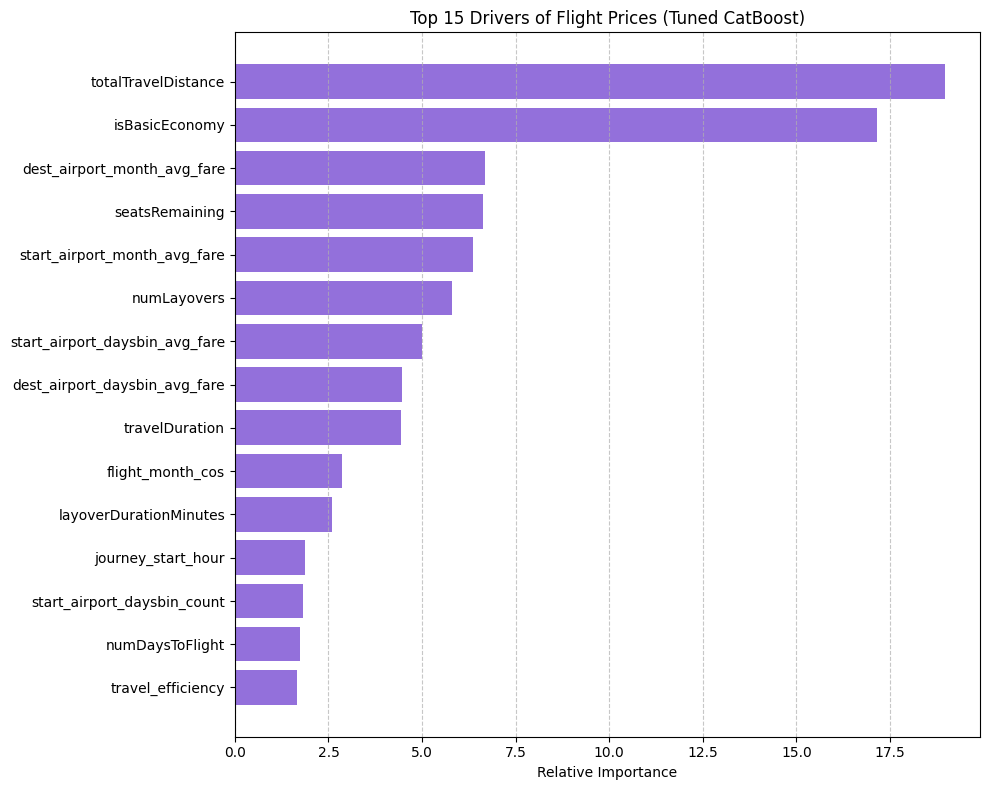

In [4]:
plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='mediumpurple')
plt.xlabel('Relative Importance')
plt.title('Top 15 Drivers of Flight Prices (Tuned CatBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=300)  # Save the figure with high resolution 
plt.show()